In [4]:
%pip install --quiet --upgrade pip
%pip install tensorflow numpy matplotlib jupyter ipykernel


Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.2 MB 6.3 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.2 MB 6.3 MB/s eta 0:00:01
   ------------------- -------------------- 3.9/8.2 MB 6.2 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.2 MB 6.2 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.2 MB 6.3 MB/s eta 0:00:01
   -------------------------------------- - 7.9/8.2 MB 6.2 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 6.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ----------------- ---------------------- 1.0/2.4 MB 6.3 MB/s eta 0:00:01
   ----------------------------------- ---- 2.1/2.4 MB 5.9 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 5.2 MB/s  0:00:00
   ---------------------------------------

# LSTM sur IMDB - Notebook complet

Ce notebook contient l'intégralité du pipeline : chargement des données IMDB (Keras), prétraitement, définition du modèle LSTM, entraînement, évaluation, sauvegarde du modèle et visualisations.

Modifiez les variables `EPOCHS` et `BATCH_SIZE` dans la cellule suivante pour ajuster l'entraînement.

In [5]:
# Imports et paramètres
import csv
import html
import os
import re

import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

# --- Hyperparamètres modifiables ---
EPOCHS = 5
BATCH_SIZE = 64
VOCAB_SIZE = 20000
MAXLEN = 200  # longueur max des séquences (tokens)
VAL_FRAC = 0.15
TEST_FRAC = 0.15
OUT_DIR = 'output'  # dossier de sortie relatif au répertoire courant
os.makedirs(OUT_DIR, exist_ok=True)

print(f'Params: epochs={EPOCHS}, batch_size={BATCH_SIZE}, vocab={VOCAB_SIZE}, maxlen={MAXLEN}')

Params: epochs=5, batch_size=64, vocab=20000, maxlen=200


In [6]:
# Chargement et prétraitement des données IMDB depuis le CSV local
CSV_PATH = 'IMDB Dataset.csv'

def clean_review(text):
    text = html.unescape(str(text))
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text

print(f'Chargement du CSV local: {CSV_PATH}')
reviews, labels = [], []
with open(CSV_PATH, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        reviews.append(clean_review(row['review']))
        labels.append(1 if row['sentiment'].strip().lower() == 'positive' else 0)

reviews = np.array(reviews, dtype=object)
labels = np.array(labels, dtype=np.int32)

# Mélange reproductible puis split 70/15/15
rng = np.random.default_rng(42)
indices = rng.permutation(len(reviews))
reviews = reviews[indices]
labels = labels[indices]

n_total = len(reviews)
n_test = int(n_total * TEST_FRAC)
n_val = int(n_total * VAL_FRAC)
n_train = n_total - n_val - n_test

x_train_texts = reviews[:n_train]
y_train = labels[:n_train]
x_val_texts = reviews[n_train:n_train + n_val]
y_val = labels[n_train:n_train + n_val]
x_test_texts = reviews[n_train + n_val:]
y_test = labels[n_train + n_val:]

# Tokenisation et padding
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train_texts)
x_train = pad_sequences(tokenizer.texts_to_sequences(x_train_texts), maxlen=MAXLEN, padding='post', truncating='post')
x_val = pad_sequences(tokenizer.texts_to_sequences(x_val_texts), maxlen=MAXLEN, padding='post', truncating='post')
x_test = pad_sequences(tokenizer.texts_to_sequences(x_test_texts), maxlen=MAXLEN, padding='post', truncating='post')

print('Shapes:', 'train=', x_train.shape, 'val=', x_val.shape, 'test=', x_test.shape)

Chargement du CSV local: IMDB Dataset.csv
Shapes: train= (35000, 200) val= (7500, 200) test= (7500, 200)


In [7]:
# Définition du modèle LSTM
def build_model(vocab_size=VOCAB_SIZE, embed_dim=128, lstm_units=128, maxlen=MAXLEN):
    model = keras.Sequential([
        layers.Embedding(vocab_size, embed_dim, input_length=maxlen),
        layers.LSTM(lstm_units, dropout=0.2, recurrent_dropout=0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

# Instanciation
model = build_model()
model.summary()

C:\Users\afagn\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Entraînement
history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val)
)

Epoch 1/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 208s 366ms/step - accuracy: 0.5615 - loss: 0.6799 - val_accuracy: 0.6144 - val_loss: 0.6609
Epoch 2/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 179s 326ms/step - accuracy: 0.6375 - loss: 0.6285 - val_accuracy: 0.6131 - val_loss: 0.6226
Epoch 3/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 167s 306ms/step - accuracy: 0.7407 - loss: 0.5328 - val_accuracy: 0.7979 - val_loss: 0.4880
Epoch 4/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 275s 503ms/step - accuracy: 0.8529 - loss: 0.3669 - val_accuracy: 0.8401 - val_loss: 0.3879
Epoch 5/5
547/547 ━━━━━━━━━━━━━━━━━━━━ 356s 651ms/step - accuracy: 0.8963 - loss: 0.2718 - val_accuracy: 0.8561 - val_loss: 0.3479


In [9]:
# Évaluation sur le jeu de test
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f}')

235/235 - 21s - 91ms/step - accuracy: 0.8561 - loss: 0.3479
Test loss: 0.3479, Test accuracy: 0.8561


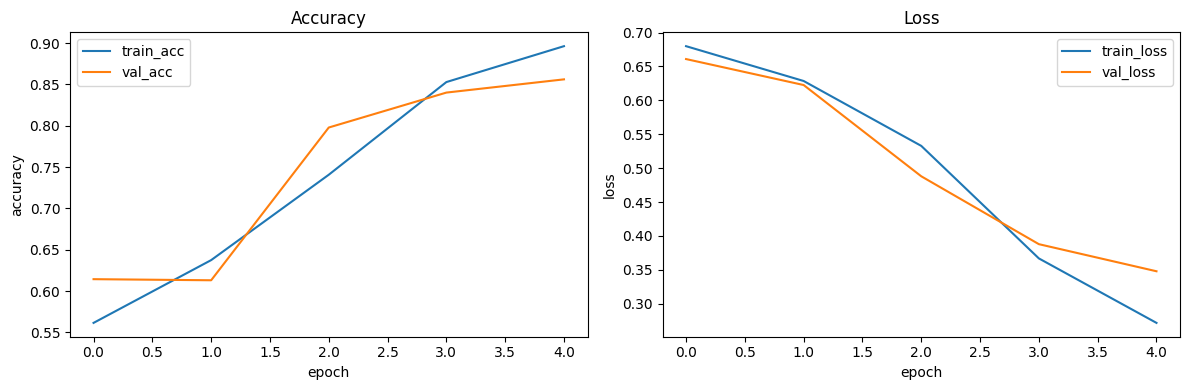

In [10]:
# Visualisations: accuracy & loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()
plt.show()